# LSTM-VAE (paper model) — Metrics

Evaluate a model trained with `train_vae.py` (the Chowdhury 2025 LSTM β-VAE).

This notebook:
1. Loads the trained bundle (`checkpoints/vae_*`) and its scaler
2. Loads held-out parquet telemetry and builds sequence windows using the **saved** scaler
3. Injects synthetic attacks (dos / fuzzing / spoof / spike / drift / frequency / replay / splice)
4. Scores benign vs attack windows with all **three detection heads**:
   reconstruction error, latent distance (BallTree), latent clustering (Isolation Forest)
5. Reports the paper's metrics for imbalanced detection: **PR AUC** and **macro F1**,
   plus AUROC and recall/FPR at the calibrated threshold
6. Plots PR curves, score distributions, and a per-attack PR-AUC breakdown

> Run from `Python scripts/vae_v1/` so `vae_model`, `train_vae`, `evaluate_vae` are importable.
> Requires: `pip install numpy pandas pyarrow scikit-learn matplotlib joblib "jax[cpu]" flax optax`

## 1. Configuration

Point these at your trained bundle and evaluation parquet data. Defaults match `train_vae.py`.

In [1]:
from pathlib import Path

# Model bundle produced by train_vae.py
BUNDLE_DIR = Path("checkpoints")
NAME       = "vae"

# Parquet file or folder to evaluate on (ideally held out from training)
DATA_PATH = Path("../../Data/new_data_processed")

MAX_EVAL_WINDOWS = 20_000   # cap for speed (uniform subsample across trace)
ATTACK_RATE      = 0.30     # attack windows injected, as a fraction of benign windows
SEED             = 42

## 2. Imports & load the trained bundle

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    average_precision_score, f1_score, roc_auc_score,
    precision_recall_curve, confusion_matrix,
)

from vae_model import LSTMVAE, FEATURES, N_FEATURES, WINDOW_SIZE, STRIDE
from train_vae import load_parquet, make_windows          # reuse loaders
from evaluate_vae import SINGLE_ATTACKS, PAIR_ATTACKS, ATTACKS, build_attack_set

np.random.seed(SEED)
rng = np.random.default_rng(SEED)

model = LSTMVAE.load(str(BUNDLE_DIR), name=NAME)
scaler = np.load(BUNDLE_DIR / f"{NAME}_scaler.npz")
MU, SD = scaler["mean"].astype(np.float32), scaler["std"].astype(np.float32)

print(f"Loaded bundle: {BUNDLE_DIR.resolve()} ({NAME})")
print(f"  config             : {model.cfg}")
print(f"  recon threshold    : {model.recon_threshold:.6f}")
print(f"  distance threshold : {model.dist_threshold:.6f}")
print(f"  scaler mean        : {np.round(MU, 3)}")
print(f"  scaler std         : {np.round(SD, 3)}")

Loaded bundle: /Users/mohazrati/Documents/Google DeepMind Research Ready/Intrusion Detection in Vehicular Systems/Unsupervised Intrusion Detection on Resource Constrained Edge Devices/implementations/base_GRU/Carla/Python scripts/vae_v1/checkpoints (vae)
  config             : VAEConfig(window=20, n_features=8, lstm_units=64, latent_dim=10, activation='tanh')
  recon threshold    : 1.981018
  distance threshold : 0.005668
  scaler mean        : [ 2.0170e+01  5.8624e+01  3.0200e-01  2.5900e-01 -1.3000e-02  1.3820e+00
  1.8137e+01  3.6473e+01]
  scaler std         : [1.2309e+01 2.6495e+01 2.3600e-01 4.3400e-01 3.8000e-02 5.9000e-01
 8.8450e+01 7.1065e+01]


## 3. Load parquet & build windows (using the saved scaler)

Sequence windows are shape `(N, WINDOW_SIZE, N_FEATURES)`. We normalise with the
**training** mean/std so the calibrated thresholds stay valid.

In [3]:
trace = load_parquet(DATA_PATH)
norm = ((trace - MU) / SD).astype(np.float32)
benign = make_windows(norm, STRIDE)
print(f"[Windows] {len(benign):,} benign (stride={STRIDE})")

if len(benign) > MAX_EVAL_WINDOWS:
    idx = np.linspace(0, len(benign) - 1, MAX_EVAL_WINDOWS, dtype=int)
    benign = benign[idx]
    print(f"[Windows] subsampled to {len(benign):,}")

[Data] loaded 3,160,814 rows from 103 file(s)
[Data] using columns:  speed_kmh<-speed_kmh, battery_level<-battery_level, throttle<-throttle, brake<-brake, steering<-steering, gear<-gear, location_x<-location_x, location_y<-location_y
[Windows] 158,040 benign (stride=20)
[Windows] subsampled to 20,000


## 4. Inject synthetic attacks

Attacks operate on z-scored windows; magnitudes are in standard deviations — same
definitions as `evaluate_vae.py`. Eight families are used (mirroring the paper's
DoS / Fuzzing / Spoofing plus additional temporal manipulations).

In [4]:
windows, labels, kinds = build_attack_set(benign, rng, ATTACK_RATE)
prevalence = float(labels.mean())
print("[Attacks] " + ", ".join(f"{k}={int((kinds == k).sum())}" for k in ATTACKS))
print(f"[Test] benign={int((labels == 0).sum()):,}  attack={int((labels == 1).sum()):,}"
      f"  prevalence={prevalence:.3f}")

[Attacks] dos=750, fuzzing=750, spoof=750, spike=750, drift=750, frequency=750, replay=750, splice=750
[Test] benign=20,000  attack=6,000  prevalence=0.231


## 5. Score every window with all three heads

- **Reconstruction**: per-window MSE (encoder + decoder), threshold = calibrated recon threshold
- **Latent distance**: Euclidean NN distance in latent space (encoder only), threshold = calibrated distance threshold
- **Latent clustering**: Isolation Forest anomaly score (encoder only), hard labels from the IF decision boundary

In [5]:
recon_scores = model.reconstruction_error(windows)
recon_pred   = (recon_scores > model.recon_threshold).astype(int)

dist_scores = model.latent_distance(windows)
dist_pred   = (dist_scores > model.dist_threshold).astype(int)

clus_scores = model.latent_cluster_score(windows)
clus_pred   = model.latent_cluster_predict(windows)

HEADS = {
    "Reconstruction":    (recon_scores, recon_pred, model.recon_threshold),
    "Latent distance":   (dist_scores,  dist_pred,  model.dist_threshold),
    "Latent clustering": (clus_scores,  clus_pred,  None),
}
print("scored", len(windows), "windows with 3 heads")

scored 26000 windows with 3 heads


## 5b. Detection latency

Latency uses the same **streaming** protocol as `mvp_v1/evaluate_central.ipynb`:
score **one window per call**, time each call, then report **p50 / p99** over all
test windows (after a short JIT / tree warm-up).

This matches live edge deployment — a new window arrives and is scored immediately.
The latent heads (distance, clustering) use only the encoder; reconstruction also
runs the decoder. Isolation Forest / BallTree still pay per-call Python overhead on
single samples; that is part of the streaming cost and is reported honestly.

In [6]:
import time

score_fns = {
    "Reconstruction":    model.reconstruction_error,   # encoder + decoder
    "Latent distance":   model.latent_distance,        # encoder + BallTree query
    "Latent clustering": model.latent_cluster_score,   # encoder + Isolation Forest
}

# Streaming protocol (same as mvp_v1): time one window per call → p50 / p99.
latency = {}   # per-head array of per-call µs

for name, fn in score_fns.items():
    fn(windows[:64])                                   # warm up (JIT compile / tree build)

    lat_us = np.empty(len(windows), dtype=np.float32)
    for i in range(len(windows)):
        t0 = time.perf_counter()
        fn(windows[i:i + 1])
        lat_us[i] = (time.perf_counter() - t0) * 1e6
    latency[name] = lat_us

    print(f"{name:18} latency p50={np.percentile(lat_us, 50):.1f}µs  "
          f"p99={np.percentile(lat_us, 99):.1f}µs")

lat_df = pd.DataFrame({
    name: {
        "latency p50 (µs)": float(np.percentile(latency[name], 50)),
        "latency p99 (µs)": float(np.percentile(latency[name], 99)),
    } for name in score_fns
}).T
lat_df.round(1)

Reconstruction     latency p50=135.1µs  p99=258.7µs
Latent distance    latency p50=487.0µs  p99=1099.9µs
Latent clustering  latency p50=2518.9µs  p99=2936.4µs


,latency p50 (µs),latency p99 (µs)
Reconstruction,135.1,258.7
Latent distance,487.0,1099.9
Latent clustering,2518.9,2936.4


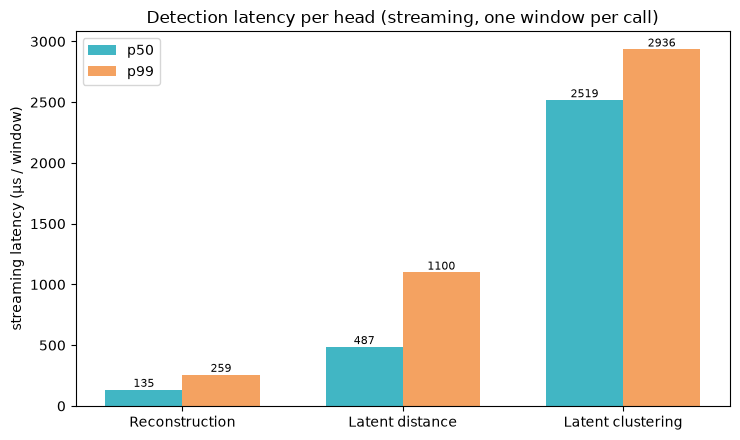

In [7]:
# Streaming latency p50 (lower = cheaper). Same protocol as mvp_v1.
heads = list(latency)
p50s = [float(np.percentile(latency[h], 50)) for h in heads]
p99s = [float(np.percentile(latency[h], 99)) for h in heads]

x = np.arange(len(heads))
width = 0.35
fig, ax = plt.subplots(figsize=(7.5, 4.5))
bars50 = ax.bar(x - width / 2, p50s, width, label="p50", color="#41b6c4")
bars99 = ax.bar(x + width / 2, p99s, width, label="p99", color="#f4a261")
for xi, (a, b) in enumerate(zip(p50s, p99s)):
    ax.text(xi - width / 2, a, f"{a:.0f}", ha="center", va="bottom", fontsize=8)
    ax.text(xi + width / 2, b, f"{b:.0f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x, heads)
ax.set_ylabel("streaming latency (µs / window)")
ax.set_title("Detection latency per head (streaming, one window per call)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Headline metrics (PR AUC + macro F1)

In [8]:
rows = []
for name, (scores, pred, thr) in HEADS.items():
    rows.append({
        "head": name,
        "PR AUC": average_precision_score(labels, scores),
        "macro F1": f1_score(labels, pred, average="macro", zero_division=0),
        "AUROC": roc_auc_score(labels, scores),
        "recall": float(pred[labels == 1].mean()),
        "FPR": float(pred[labels == 0].mean()),
        "latency p50 (µs)": float(np.percentile(latency[name], 50)),
        "latency p99 (µs)": float(np.percentile(latency[name], 99)),
    })
summary = pd.DataFrame(rows).set_index("head")
print(f"random-baseline PR AUC = prevalence = {prevalence:.3f}\n")
summary.round(3)

random-baseline PR AUC = prevalence = 0.231



,PR AUC,macro F1,AUROC,recall,FPR,latency p50 (µs),latency p99 (µs)
head,,,,,,,
Reconstruction,0.599,0.718,0.735,0.378,0.015,135.083,258.668
Latent distance,0.874,0.814,0.925,0.531,0.000,487.021,1099.875
Latent clustering,0.801,0.754,0.862,0.424,0.005,2518.875,2936.382


## 7. Precision–Recall curves (all heads)

PR AUC (average precision) is the paper's primary metric — more informative than ROC
when attacks are rare. The dashed line is the random baseline (= attack prevalence).

> **Reading the reconstruction curve (why it looks like a "plateau then cliff", not a bug).**
> The reconstruction head sits near **precision ≈ 1.0 up to some recall (~0.4)** and then
> **drops sharply toward the baseline**. This step shape is *expected*, not a plotting error.
> It happens because the reconstruction error separates attacks into two groups:
>
> * **Large-magnitude / widespread attacks** (DoS, fuzzing, spoofing) blow up the MSE
>   (error ≈ 3–10× benign) → they occupy the very top scores → perfect precision at low recall.
> * **Subtle temporal attacks** (spike, drift, frequency, replay, splice) barely move the MSE
>   (error ≈ benign). The encoder does **global average pooling over the 50-step window** and the
>   decoder rebuilds from a single pooled latent, so a one-cell change adds only ≈ 0.16 to the
>   MSE — invisible. These attacks fall *inside* the benign score cloud, so once the easy attacks
>   are exhausted, precision collapses to prevalence → the cliff.
>
> This is exactly why the paper adds the **latent-distance and latent-clustering heads** — they
> catch the subtle attacks the reconstruction head is blind to. Compare the curves below and the
> per-attack breakdown in §9.
>
> If instead your reconstruction curve is **flat at the baseline everywhere** (no plateau), that
> is **posterior collapse** (decoder predicting the mean; symptom: training loss ≈ 1.0). Fix by
> lowering `--beta` (e.g. 0.1–0.3), training more epochs, and/or increasing `--lstm-units`.

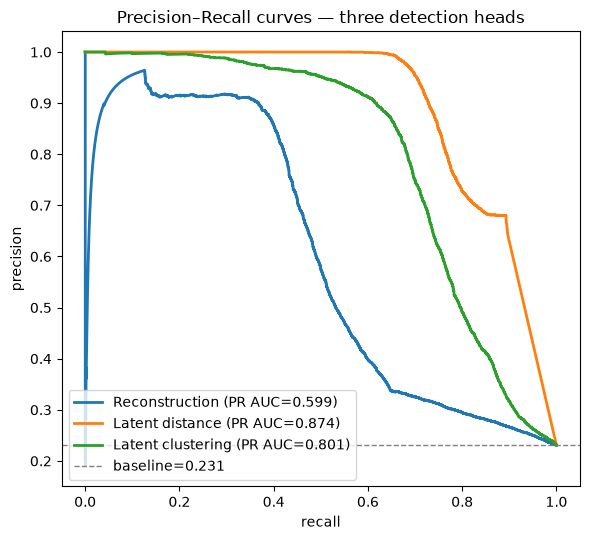

In [9]:
fig, ax = plt.subplots(figsize=(6, 5.5))
for name, (scores, pred, thr) in HEADS.items():
    prec, rec, _ = precision_recall_curve(labels, scores)
    ap = average_precision_score(labels, scores)
    ax.plot(rec, prec, lw=2, label=f"{name} (PR AUC={ap:.3f})")
ax.axhline(prevalence, ls="--", color="gray", lw=1, label=f"baseline={prevalence:.3f}")
ax.set_xlabel("recall")
ax.set_ylabel("precision")
ax.set_title("Precision–Recall curves — three detection heads")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

## 8. Score distributions (benign vs attack)

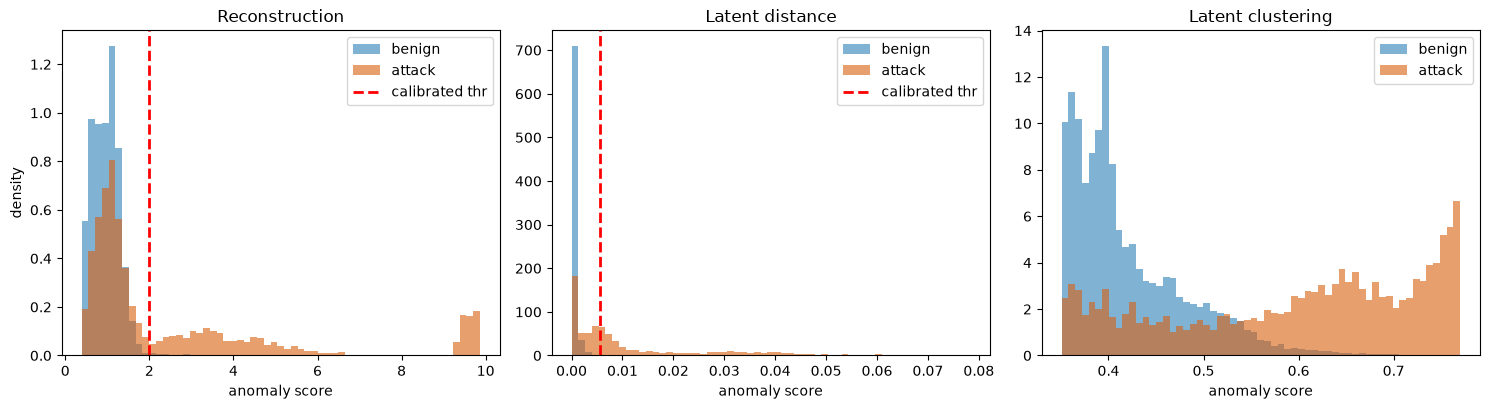

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (name, (scores, pred, thr)) in zip(axes, HEADS.items()):
    b = scores[labels == 0]
    a = scores[labels == 1]
    lo, hi = np.percentile(scores, 1), np.percentile(scores, 99)
    bins = np.linspace(lo, hi, 60)
    ax.hist(b, bins=bins, alpha=0.6, density=True, color="#2c7fb8", label="benign")
    ax.hist(a, bins=bins, alpha=0.6, density=True, color="#d95f0e", label="attack")
    if thr is not None:
        ax.axvline(thr, color="red", ls="--", lw=2, label="calibrated thr")
    ax.set_title(name)
    ax.set_xlabel("anomaly score")
    ax.legend()
axes[0].set_ylabel("density")
plt.tight_layout()
plt.show()

## 9. Per-attack PR AUC (each family vs benign)

Threshold-independent — shows how detectable each attack family is for each head.

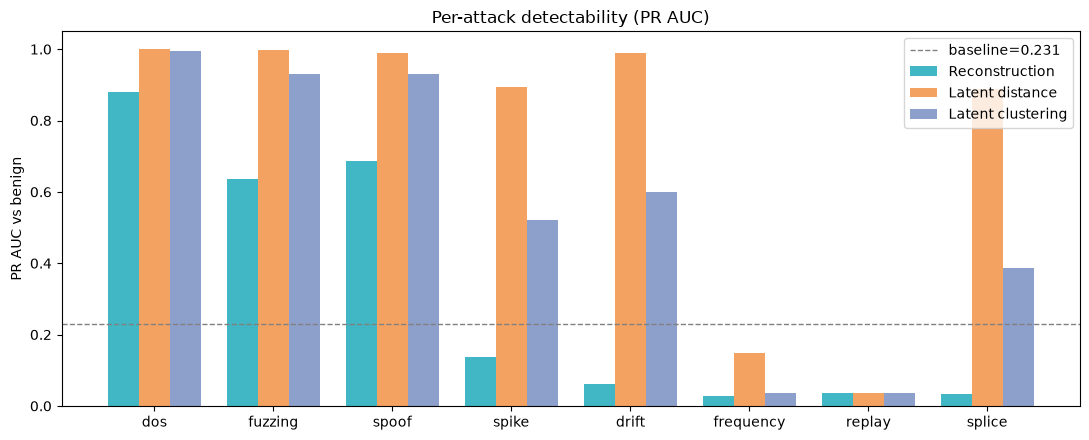

,Reconstruction,Latent distance,Latent clustering
attack,,,
dos,0.880,1.000,0.996
fuzzing,0.635,0.999,0.929
spoof,0.686,0.989,0.931
spike,0.139,0.894,0.522
drift,0.060,0.989,0.601
frequency,0.029,0.148,0.038
replay,0.036,0.036,0.037
splice,0.033,0.888,0.388


In [11]:
rows = []
for k in ATTACKS:
    m = (kinds == k) & (labels == 1)
    if not m.any():
        continue
    row = {"attack": k}
    for name, (scores, pred, thr) in HEADS.items():
        benign_s = scores[labels == 0]
        y = np.concatenate([np.zeros(len(benign_s)), np.ones(int(m.sum()))])
        s = np.concatenate([benign_s, scores[m]])
        row[name] = average_precision_score(y, s)
    rows.append(row)
per_attack = pd.DataFrame(rows).set_index("attack")

x = np.arange(len(per_attack))
width = 0.26
colors = ["#41b6c4", "#f4a261", "#8da0cb"]
fig, ax = plt.subplots(figsize=(11, 4.5))
for i, name in enumerate(HEADS):
    ax.bar(x + (i - 1) * width, per_attack[name], width, label=name, color=colors[i])
ax.axhline(prevalence, color="gray", ls="--", lw=1, label=f"baseline={prevalence:.3f}")
ax.set_xticks(x, per_attack.index)
ax.set_ylim(0, 1.05)
ax.set_ylabel("PR AUC vs benign")
ax.set_title("Per-attack detectability (PR AUC)")
ax.legend()
plt.tight_layout()
plt.show()

per_attack.round(3)

## 10. Reading the results

- **PR AUC** and **macro F1** are the paper's chosen metrics for this imbalanced setting
  (Sec. 4.1.1 / 4.3). PR AUC well above the prevalence baseline means the score ranks
  attacks above benign traffic.
- The **latent** heads (distance, clustering) use only the encoder at inference — the
  paper's efficiency win. Compare their PR AUC to the reconstruction head to see the
  accuracy/compute trade-off on your data.
- **Latency p50 / p99** use the same streaming protocol as `mvp_v1` (one window per call),
  so they are comparable across models. Latent clustering's streaming cost includes
  Isolation Forest's per-sample Python overhead.
- **recall / FPR** are at the calibrated threshold. If PR AUC is high but recall is low,
  the threshold is too conservative — lower the margin (`--margin`) in `train_vae.py`,
  or train the latent-objective model (`--objective latent`, β=2) for the latent heads.
- A per-attack PR AUC near the baseline means that family is effectively invisible to
  that head.